In [ ]:
# Run in case you dont have awswrangler already installed!
# !pip install awswrangler

In [1]:
import pandas as pd
import boto3
import awswrangler as wr

In [2]:
df = pd.read_csv("diabetic_data.csv")

print(df.shape)

df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Here below is where I create a TEMPORARY s3 bucket. This is temporary becuase we have 3 seperate aws accounts. So I figured that Divya can use this code to create her own (REAL) s3 account. This means she will have to be the owner of the infrastcture so after she creates her model, anything we do after, we have to send her the code to run using her S3 account in order for it to work.

In [3]:
# config
BUCKET_NAME = "aai540-diabetes-readmission-gaius-test" # <---- DIVYA CHANGE THIS TO THE FINAL BUCKET NAME
REGION = "us-east-1"

# s3 client
s3_client = boto3.client("s3", region_name=REGION)

# bucket
try:
    if REGION == "us-east-1":
        s3_client.create_bucket(Bucket=BUCKET_NAME)
    else:
        s3_client.create_bucket(
            Bucket=BUCKET_NAME,
            CreateBucketConfiguration={
                "LocationConstraint": REGION
            }
        )

    print(f"Bucket '{BUCKET_NAME}' created successfully!")

except Exception as e:
    print("Error creating bucket:")
    print(e)

Bucket 'aai540-diabetes-readmission-gaius-test' created successfully!


In [15]:
#create folders

folders = [
    "raw/diabetic_data/",
    "raw/mappings/"
]

for folder in folders:
    s3_client.put_object(
        Bucket=BUCKET_NAME,
        Key=folder
    )

print("New folders created!")

New folders created!


In [16]:
#upload files

# Upload main dataset
s3_client.upload_file(
    "diabetic_data.csv",
    BUCKET_NAME,
    "raw/diabetic_data/diabetic_data.csv"
)

# Upload mapping file
s3_client.upload_file(
    "IDS_mapping.csv",
    BUCKET_NAME,
    "raw/mappings/IDS_mapping.csv"
)

print("Files uploaded into separated folders!")

Files uploaded into separated folders!


In [19]:
#Create query

create_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS diabetic_readmissions (
    encounter_id BIGINT,
    patient_nbr BIGINT,
    race STRING,
    gender STRING,
    age STRING,
    weight STRING,
    admission_type_id INT,
    discharge_disposition_id INT,
    admission_source_id INT,
    time_in_hospital INT,
    payer_code STRING,
    medical_specialty STRING,
    num_lab_procedures INT,
    num_procedures INT,
    num_medications INT,
    number_outpatient INT,
    number_emergency INT,
    number_inpatient INT,
    diag_1 STRING,
    diag_2 STRING,
    diag_3 STRING,
    number_diagnoses INT,
    max_glu_serum STRING,
    A1Cresult STRING,
    metformin STRING,
    insulin STRING,
    change STRING,
    diabetesMed STRING,
    readmitted STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    "separatorChar" = ",",
    "quoteChar" = "\\""
)
LOCATION 's3://{BUCKET_NAME}/raw/diabetic_data/'
TBLPROPERTIES ("skip.header.line.count"="1");
"""

In [20]:
#create athena table 

wr.athena.start_query_execution(
    sql=create_table_query,
    database=DATABASE_NAME,
    s3_output=ATHENA_OUTPUT
)

print("Athena table recreated successfully!")

Athena table recreated successfully!


In [22]:
#test query

query = """
SELECT *
FROM diabetic_readmissions
LIMIT 10
"""

results = wr.athena.read_sql_query(
    sql=query,
    database=DATABASE_NAME,
    s3_output=ATHENA_OUTPUT
)

results.head()

2026-05-22 15:10:24,775	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1909436416 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.54gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-22 15:10:25,916	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,diag_2,diag_3,number_diagnoses,max_glu_serum,a1cresult,metformin,insulin,change,diabetesmed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,?,?,1,None,None,No,No,No,No,No
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,250.01,255,9,None,None,No,No,No,No,No
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,250,V27,6,None,None,No,No,No,No,No
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,250.43,403,7,None,None,No,No,No,No,No
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,157,250,5,None,None,No,No,No,No,No


In [23]:
# I created this to help us see the athena table and the folder structure in a ui format


session = boto3.session.Session()
region = session.region_name

ACCOUNT_ID = boto3.client("sts").get_caller_identity()["Account"]

BUCKET_NAME = BUCKET_NAME
DATABASE_NAME = DATABASE_NAME

# S3 console link (bucket)
s3_console_url = f"https://s3.console.aws.amazon.com/s3/buckets/{BUCKET_NAME}?region={region}&tab=objects"

# Athena console link
athena_console_url = f"https://{region}.console.aws.amazon.com/athena/home?region={region}#query/editor"

print("S3 Bucket UI:", s3_console_url)
print("Athena UI:", athena_console_url)
print("Database:", DATABASE_NAME)

S3 Bucket UI: https://s3.console.aws.amazon.com/s3/buckets/aai540-diabetes-readmission-gaius-test?region=us-east-1&tab=objects
Athena UI: https://us-east-1.console.aws.amazon.com/athena/home?region=us-east-1#query/editor
Database: diabetes_mlops_db


# Exploratory Data Analysis

In [24]:
#df is from above with the diabetic data csv

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
print(df["readmitted"].value_counts(normalize=True))

df.head()

Shape: (101766, 50)

Missing values:
 max_glu_serum               96420
A1Cresult                   84748
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
dtype: int64

Target distribution:
readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


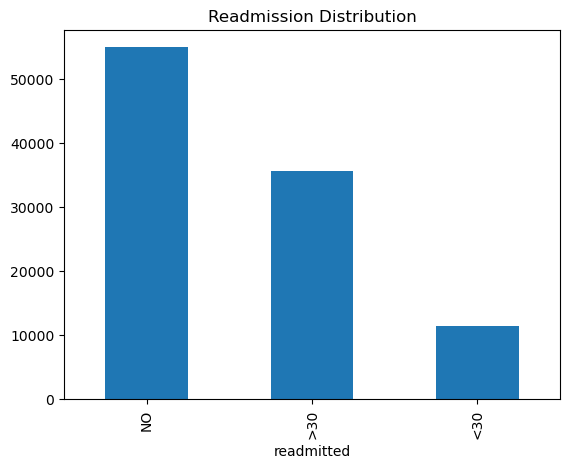

In [25]:
#quick distribution

import matplotlib.pyplot as plt

df["readmitted"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.show()

# FEEL FREE TO ADD MORE EDA (according to your background in bio)

In [26]:
#starts feature store
import os

feature_store_path = f"s3://{BUCKET_NAME}/feature-store/"
print("Feature Store Path:", feature_store_path)

Feature Store Path: s3://aai540-diabetes-readmission-gaius-test/feature-store/


In [27]:
#set features 
#DIVYA PLEASE FEEL FREE TO USE YOUR BACKGROUND KNOWLEDGE TO SELECT GOOD FEATURES

features = [
    "race",
    "gender",
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "change",
    "diabetesMed"
]

target = "readmitted"

In [28]:
#clean readmitted
df["readmitted"] = df["readmitted"].replace({
    "NO": 0,
    "<30": 1,
    ">30": 0
})

/tmp/ipykernel_756/1682652690.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["readmitted"] = df["readmitted"].replace({


In [29]:
#select features and encode categorical variables  and store in feature store
df_model = df[features + [target]].copy()

df_model = pd.get_dummies(df_model, drop_first=True)

df_model.to_csv(f"/tmp/features.csv", index=False)


s3 = boto3.client("s3")

s3.upload_file(
    "/tmp/features.csv",
    BUCKET_NAME,
    "feature-store/features.csv"
)

print("Feature store dataset uploaded")

Feature store dataset uploaded


In [30]:
#split data
# train 40%, valid 10%, test 10%, save 40% for prod (all from the professors instructions)

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_model, test_size=0.6, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.1667, random_state=42)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 40706
Val: 50881
Test: 10179


In [31]:
# instructions say to save this for later
production_df = temp_df.copy()

print("Production set:", len(production_df))

Production set: 61060


In [32]:
# now push this all the S3 bucket

train_df.to_csv("/tmp/train.csv", index=False)
val_df.to_csv("/tmp/val.csv", index=False)
test_df.to_csv("/tmp/test.csv", index=False)
production_df.to_csv("/tmp/production.csv", index=False)

s3.upload_file("/tmp/train.csv", BUCKET_NAME, "processed/train.csv")
s3.upload_file("/tmp/val.csv", BUCKET_NAME, "processed/val.csv")
s3.upload_file("/tmp/test.csv", BUCKET_NAME, "processed/test.csv")
s3.upload_file("/tmp/production.csv", BUCKET_NAME, "production/production.csv")

print("All datasets uploaded to S3")

All datasets uploaded to S3
